<a href="https://colab.research.google.com/github/soumnemishra/snap_tune/blob/main/Resnet_model_training_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive') #mounting drive

Mounted at /content/drive


TRF RECORDS VALIDATIONS CHECKS

In [ ]:
import tensorflow as tf
import glob
import os
from tqdm import tqdm

# Base path
base_path = "/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed"
splits = ["train", "val", "test"]

# Define parser
def parse_check(example):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64)
    }
    example = tf.io.parse_single_example(example, feature_description)
    image = tf.io.parse_tensor(example['image'], out_type=tf.float32)
    label = example['label']
    return image, label

# Loop through splits
for split in splits:
    pattern = os.path.join(base_path, f"{split}_chunk_*.tfrecord")
    tfrecord_files = glob.glob(pattern)

    print(f"\n=== Checking split: {split.upper()} ===")
    print(f"Found {len(tfrecord_files)} TFRecord files")

    global_min = float('inf')
    global_max = float('-inf')
    total_samples = 0
    current_shape = None  # To capture the shape

    progress = tqdm(tfrecord_files, desc=f"Processing {split}", unit="file", position=0)

    for file in progress:
        dataset = tf.data.TFRecordDataset(file).map(parse_check)
        file_sample_count = 0

        for image, _ in dataset:
            img_min = tf.reduce_min(image).numpy()
            img_max = tf.reduce_max(image).numpy()

            shape = tuple(image.shape)
            current_shape = shape

            global_min = min(global_min, img_min)
            global_max = max(global_max, img_max)

            total_samples += 1
            file_sample_count += 1

            # Live update: file name, count, min/max, shape
            progress.set_description(
                f"{split.upper()} | {os.path.basename(file)} | Samples: {file_sample_count} "
                f"| Min: {img_min:.3f} | Max: {img_max:.3f} | Shape: {shape}"
            )

    print(f"\nTotal Samples in {split}: {total_samples}") #
    print(f"Global Min Pixel Value: {global_min}")
    print(f"Global Max Pixel Value: {global_max}")
    print(f"Expected: dtype=float32, values in [0, 1]\n")



=== Checking split: TRAIN ===
Found 23 TFRecord files


TRAIN | train_chunk_20.tfrecord | Samples: 2000 | Min: 0.002 | Max: 0.983 | Shape: (224, 224, 3): 100%|██████████| 23/23 [11:52<00:00, 30.96s/file]



Total Samples in train: 45304
Global Min Pixel Value: 0.0
Global Max Pixel Value: 1.0
Expected: dtype=float32, values in [0, 1]


=== Checking split: VAL ===
Found 6 TFRecord files


VAL | val_chunk_5.tfrecord | Samples: 1326 | Min: 0.000 | Max: 0.824 | Shape: (224, 224, 3): 100%|██████████| 6/6 [03:15<00:00, 32.56s/file]



Total Samples in val: 11326
Global Min Pixel Value: 0.0
Global Max Pixel Value: 1.0
Expected: dtype=float32, values in [0, 1]


=== Checking split: TEST ===
Found 4 TFRecord files


TEST | test_chunk_3.tfrecord | Samples: 286 | Min: 0.019 | Max: 0.938 | Shape: (224, 224, 3): 100%|██████████| 4/4 [01:55<00:00, 28.80s/file]


Total Samples in test: 6286
Global Min Pixel Value: 0.0
Global Max Pixel Value: 1.0
Expected: dtype=float32, values in [0, 1]



In [ ]:
import tensorflow as tf
import numpy as np
def parse_tfrecord(example):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64)
    }
    example = tf.io.parse_single_example(example, feature_description)
    image = tf.io.parse_tensor(example['image'], out_type=tf.float32)
    image = tf.ensure_shape(image, [224, 224, 3])
    label = tf.one_hot(tf.cast(example['label'], tf.int32), depth=7)
    return image, label

for split in ['train', 'val', 'test']:
    for file in tf.io.gfile.glob(f'/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/{split}_chunk_*.tfrecord'):
        count = sum(1 for _ in tf.data.TFRecordDataset(file).map(parse_tfrecord))
        y_true = [np.argmax(label.numpy()) for _, label in tf.data.TFRecordDataset(file).map(parse_tfrecord)]
        print(f"{file}: {count} samples, classes: {np.unique(y_true)}")

/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/train_chunk_0.tfrecord: 2000 samples, classes: [0 1 2 3 4 5 6]
/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/train_chunk_3.tfrecord: 2000 samples, classes: [0 1 2 3 4 5 6]
/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/train_chunk_4.tfrecord: 2000 samples, classes: [0 1 2 3 4 5 6]
/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/train_chunk_1.tfrecord: 2000 samples, classes: [0 1 2 3 4 5 6]
/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/train_chunk_5.tfrecord: 2000 samples, classes: [0 1 2 3 4 5 6]
/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/train_chunk_2.tfrecord: 2000 samples, classes: [0 1 2 3 4 5 6]
/content/drive/M

# VISUALIZING THE SAMPLES

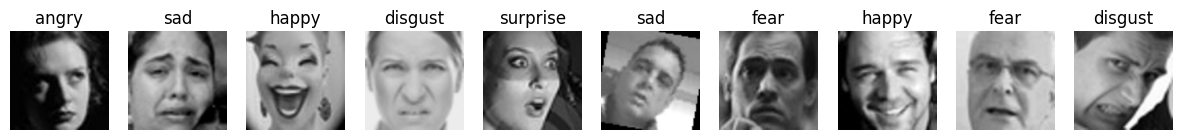

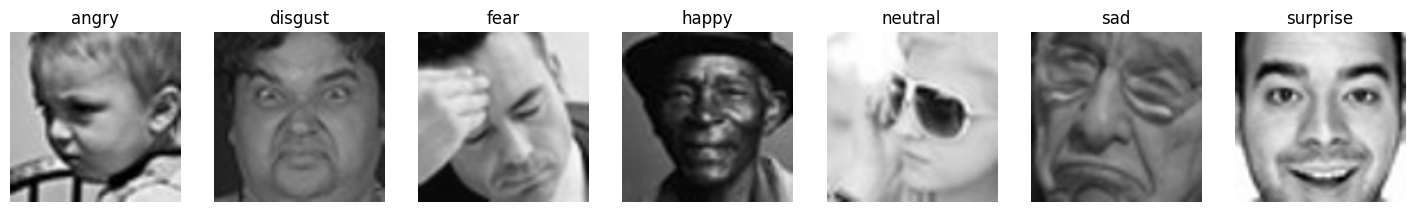

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

# Define emotion classes
EMOTION_CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# --- Parsing function ---
def parse_tfrecord(example):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64)
    }
    example = tf.io.parse_single_example(example, feature_description)
    image = tf.io.parse_tensor(example['image'], out_type=tf.float32)
    image = tf.ensure_shape(image, [224, 224, 3])  # Ensure correct shape
    label = tf.cast(example['label'], tf.int32)
    return image, label

# --- Function to normalize and handle grayscale ---
def prepare_image(img):
    img = img.numpy()

    # Normalize only if needed
    if img.max() > 1.0:
        img = img / 255.0

    # If grayscale (last channel = 1), remove it
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
        return img, 'gray'
    else:
        return img, None  # RGB, no colormap

# --- Visualize N random images ---
def visualize_random_images(tfrecord_files, num_images=10):
    dataset = tf.data.TFRecordDataset(tfrecord_files)
    dataset = dataset.map(parse_tfrecord).shuffle(5000)
    samples = list(dataset.take(num_images))

    plt.figure(figsize=(15, 6))
    for i, (image, label) in enumerate(samples):
        img, cmap = prepare_image(image)
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img, cmap=cmap)
        plt.title(EMOTION_CLASSES[label.numpy()])
        plt.axis('off')
    plt.show()

# --- Visualize one random image per class ---
def visualize_one_per_class(tfrecord_files, num_classes=7):
    dataset = tf.data.TFRecordDataset(tfrecord_files)
    dataset = dataset.map(parse_tfrecord)

    all_data = list(dataset)
    class_dict = {i: [] for i in range(num_classes)}

    for img, lbl in all_data:
        class_dict[lbl.numpy()].append(img)

    plt.figure(figsize=(18, 6))
    for i in range(num_classes):
        if class_dict[i]:
            img, cmap = prepare_image(random.choice(class_dict[i]))
            plt.subplot(1, num_classes, i + 1)
            plt.imshow(img, cmap=cmap)
            plt.title(EMOTION_CLASSES[i])
            plt.axis('off')
    plt.show()

# --- Example usage ---
tfrecord_files = tf.io.gfile.glob(f'/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/{split}_chunk_*.tfrecord')

# Show 10 random images
visualize_random_images(tfrecord_files, num_images=10)

# Show 1 random image per class
visualize_one_per_class(tfrecord_files, num_classes=7)


In [ ]:
    import tensorflow as tf
    import numpy as np
    import os
    import time
    import re
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from google.colab import drive
    from datetime import datetime

    # Import scikit-learn metrics for PerformanceMonitor
    from sklearn.metrics import confusion_matrix, classification_report

    import gc
    from tqdm.notebook import tqdm
    import psutil
    from tensorflow.keras.optimizers import AdamW
    from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

    # --- Configuration Constants ---
    EMOTION_CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    IMAGE_SIZE = (224, 224)

    # --- OUTPUT_DIR FOR NEW RUNS (RECOMMENDED FOR A FRESH START) ---
    # THESE LINES MUST BE UNCOMMENTED TO CREATE A BRAND NEW, CLEAN DIRECTORY.
    TIMESTAMP = datetime.now().strftime("%Y%m%d-%H%M%S")
    OUTPUT_BASE_DIR = '/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013'
    OUTPUT_DIR = os.path.join(OUTPUT_BASE_DIR, f'resnet_models_run_{TIMESTAMP}') # <--- THIS WILL BE A NEW, UNIQUE FOLDER
    print(f"New run will save outputs to: {OUTPUT_DIR}")
    # --- END MODIFIED OUTPUT_DIR ---
    #OUTPUT_DIR='/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/resnet_models_run_20250804-112056'

    # THIS LINE MUST BE COMMENTED OUT. If it's uncommented, it overrides the timestamped directory.
    # OUTPUT_DIR='/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/resnet_models_run_20250801-060741'

    # --- PREPROCESSED_DIR (KEEP AS IS) ---
    PREPROCESSED_DIR = '/content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed'

    CACHE_DIR = '/tmp/cache_v2_resnet' # Changed cache dir name to avoid conflicts

    # Training Hyperparameters - Initial suggestions, fine-tune these
    FEATURE_EXTRACT_EPOCHS = 10
    PARTIAL_FINE_TUNE_EPOCHS = 30
    FULL_FINE_TUNE_EPOCHS = 60
    INITIAL_LR_FE = 3e-4 # Slightly lower for ResNet Feature Extraction
    INITIAL_LR_PT = 8e-6 # Slightly lower for ResNet Partial Fine-tuning
    INITIAL_LR_FT = 5e-8
    BATCH_SIZE_DEFAULT = 8 # Default batch size, adjusted by strategy

    # --- Resource Management and Strategy Setup ---
    def check_resources(min_ram_gb=12, min_disk_gb=15, drive_path='/content/drive/MyDrive'):
        """Checks available RAM and disk space, prints warnings if below minimums."""
        ram_gb = psutil.virtual_memory().available / 1024**3
        disk_tmp_gb = psutil.disk_usage('/tmp').free / 1024**3
        disk_drive_gb = psutil.disk_usage(drive_path).free / 1024**3
        disk_gb = min(disk_tmp_gb, disk_drive_gb)

        print(f"\n--- Resource Availability Check ---")
        print(f"Available RAM: {ram_gb:.2f} GB (Recommended: >{min_ram_gb} GB)")
        print(f"Available Disk (temp): {disk_tmp_gb:.2f} GB")
        print(f"Available Disk (drive): {disk_drive_gb:.2f} GB (Recommended: >{min_disk_gb} GB)")

        if ram_gb < min_ram_gb:
            print(f"WARNING: Low RAM detected. This may lead to slower training or crashes.")
        if disk_gb < min_disk_gb:
            print(f"WARNING: Low disk space detected. Caching may be limited.")
        print(f"-----------------------------------")
        return ram_gb, disk_gb

    # Set memory growth and distribution strategy
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            strategy = tf.distribute.MirroredStrategy()
            tf.keras.mixed_precision.set_global_policy('mixed_float16')
            print(f"GPU initialized. Using MirroredStrategy with {strategy.num_replicas_in_sync} replicas.")
            print(f"Mixed precision (float16) enabled for GPU training.")
            BATCH_SIZE = BATCH_SIZE_DEFAULT * strategy.num_replicas_in_sync
            print(f"Global batch size set to {BATCH_SIZE} (default {BATCH_SIZE_DEFAULT} * {strategy.num_replicas_in_sync} replicas).")
        except RuntimeError as e:
            print(f"Memory growth could not be set or MirroredStrategy failed: {e}")
            strategy = tf.distribute.get_strategy()
            tf.keras.mixed_precision.set_global_policy('float32')
            BATCH_SIZE = BATCH_SIZE_DEFAULT
            print(f"Fallback to default strategy (CPU/single GPU) with batch size {BATCH_SIZE}. Mixed precision disabled.")
    else:
        strategy = tf.distribute.get_strategy()
        tf.keras.mixed_precision.set_global_policy('float32')
        print(f"No GPU found. Using CPU strategy. Mixed precision disabled.")

        ram_gb, _ = check_resources(min_ram_gb=12, min_disk_gb=15)
        if ram_gb < 8:
            BATCH_SIZE = max(1, BATCH_SIZE_DEFAULT // 8)
            print(f"WARNING: Very low RAM detected ({ram_gb:.2f} GB). Batch size aggressively reduced to {BATCH_SIZE}.")
        elif ram_gb < 16:
            BATCH_SIZE = max(1, BATCH_SIZE_DEFAULT // 4)
            print(f"WARNING: Low RAM detected ({ram_gb:.2f} GB). Batch size reduced to {BATCH_SIZE}.")
        else:
            BATCH_SIZE = BATCH_SIZE_DEFAULT // 2
            print(f"Decent RAM for CPU detected ({ram_gb:.2f} GB). Batch size set to {BATCH_SIZE}.")

        if BATCH_SIZE == 1:
            print("CRITICAL WARNING: Batch size is 1. Training will be very slow and may be unstable.")
            print("Consider upgrading to Colab Pro/Pro+ or reducing IMAGE_SIZE further.")

    # --- Mount Google Drive and Final Resource Check ---
    # Explicitly mount Google Drive before proceeding
    try:
        print("Attempting to mount Google Drive...")
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Error mounting Google Drive: {e}")
        print("Please ensure Google Drive is accessible and try again.")
        # Depending on the severity, you might want to exit or raise the exception
        # For now, we'll let it proceed, but subsequent file operations might fail.


    ram_final, disk_final = check_resources(min_ram_gb=12, min_disk_gb=15)

    # --- Directory Creation and Cache Clearing ---
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Output directory {OUTPUT_DIR} ensured.")

    import shutil
    if os.path.exists(CACHE_DIR):
        print(f"Clearing existing cache directory: {CACHE_DIR}")
        shutil.rmtree(CACHE_DIR)
    os.makedirs(CACHE_DIR, exist_ok=True)
    print(f"Cache directory {CACHE_DIR} ensured.")

    # Load class weights
    class_weights_path = os.path.join(PREPROCESSED_DIR, 'class_weights.npy')
    if not os.path.exists(class_weights_path):
        raise FileNotFoundError(f"class_weights.npy not found in {PREPROCESSED_DIR}. Please ensure your preprocessing step generates this file.")
    class_weights_dict = np.load(class_weights_path, allow_pickle=True).item()
    class_weights = {int(k): v for k, v in class_weights_dict.items()}
    print(f"Loaded class weights: {class_weights}")

GPU initialized. Using MirroredStrategy with 1 replicas.
Mixed precision (float16) enabled for GPU training.
Global batch size set to 8 (default 8 * 1 replicas).
Attempting to mount Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.

--- Resource Availability Check ---
Available RAM: 10.71 GB (Recommended: >12 GB)
Available Disk (temp): 74.42 GB
Available Disk (drive): 65.62 GB (Recommended: >15 GB)
-----------------------------------
Output directory /content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/resnet_models_run_20250804-112056 ensured.
Cache directory /tmp/cache_v2_resnet ensured.
Loaded class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}


# custom layers


In [ ]:
# --- Custom Layers and Loss (No Changes Needed Here) ---
# This block is perfectly fine as is.
class SpatialChannelAttention(tf.keras.layers.Layer):
    def __init__(self, reduction_ratio=8, **kwargs):
        super(SpatialChannelAttention, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.channel_conv = tf.keras.layers.Dense(channels // self.reduction_ratio, activation='relu', name='channel_attention_reduce')
        self.channel_fc = tf.keras.layers.Dense(channels, activation='sigmoid', name='channel_attention_expand')
        self.spatial_conv = tf.keras.layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid', use_bias=False, name='spatial_attention_conv')
        super().build(input_shape)

    def call(self, inputs):
        # Channel Attention
        avg_pool = tf.reduce_mean(inputs, axis=[1, 2], keepdims=True)
        channel_attention = self.channel_fc(self.channel_conv(avg_pool))
        x_channel = inputs * channel_attention

        # Spatial Attention
        spatial_attention = self.spatial_conv(x_channel)
        return x_channel * spatial_attention

    def get_config(self):
        config = super().get_config()
        config.update({'reduction_ratio': self.reduction_ratio})
        return config

class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.5, alpha=None, from_logits=False, reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE, name='focal_loss'):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.alpha = tf.constant(alpha, dtype=tf.float32) if alpha is not None else None
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce_loss = -y_true * tf.math.log(y_pred)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_weight = tf.expand_dims(tf.pow(1 - p_t, self.gamma), axis=-1)

        if self.alpha is not None:
            alpha_t = tf.expand_dims(tf.reduce_sum(y_true * tf.expand_dims(self.alpha, 0), axis=-1), axis=-1)
            focal_weight *= alpha_t

        focal_loss = tf.reduce_sum(focal_weight * ce_loss, axis=-1)
        return tf.reduce_mean(focal_loss)

In [ ]:
def parse_tfrecord(example):
    """
    Parses a single TFRecord example, extracts image and label.
    Resizes image to IMAGE_SIZE (224x224) and ensures 3 channels.
    """
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64)
    }
    example = tf.io.parse_single_example(example, feature_description)

    image = tf.io.parse_tensor(example['image'], out_type=tf.float32)

    # --- FIX: Update expected shape to IMAGE_SIZE (224x224x3) ---
    image = tf.ensure_shape(image, [IMAGE_SIZE[0], IMAGE_SIZE[1], 3])

    # The following line will now be a no-op if images are already 224x224,
    # but it ensures consistency if there's any variation.
    image = tf.image.resize(image, IMAGE_SIZE, method=tf.image.ResizeMethod.BILINEAR)

    label = tf.one_hot(tf.cast(example['label'], tf.int32), depth=len(EMOTION_CLASSES))
    return image, label

def load_dataset(pattern, batch_size, cache_file=None, augment=False, repeat=True):
    """
    Loads TFRecord files into a tf.data.Dataset, applies preprocessing and augmentation.
    """
    files = tf.io.gfile.glob(pattern)
    if not files:
        raise FileNotFoundError(f"No TFRecord files found for pattern: {pattern}")
    print(f"Loading {len(files)} TFRecord files for pattern: {pattern}")

    dataset = tf.data.TFRecordDataset(files, num_parallel_reads=tf.data.AUTOTUNE)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)

    # Apply on-the-fly augmentation BEFORE ResNet preprocessing
    if augment:
        data_augmentation_layers = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(factor=0.1, fill_mode='nearest'),
            tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode='nearest'),
            tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode='nearest'),
        ], name="data_augmentation")

        def apply_augmentations(image, label):
            image = data_augmentation_layers(image, training=True)
            image = tf.image.random_brightness(image, max_delta=0.2)
            image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
            image = tf.image.random_hue(image, max_delta=0.1)
            image = tf.clip_by_value(image, 0.0, 1.0) # Ensure pixel values are within 0-1 after augmentation
            return image, label

        dataset = dataset.map(apply_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
        print("Data augmentation enabled.")

    # CRITICAL: Apply ResNet's specific preprocessing.
    # Images from TFRecords are [0, 1] float32. Preprocess_input expects [0, 255].
    # So, multiply by 255.0 before passing.
    print("Applying tf.keras.applications.resnet_v2.preprocess_input...")
    dataset = dataset.map(lambda img, label: (tf.keras.applications.resnet_v2.preprocess_input(img * 255.0), label),
                          num_parallel_calls=tf.data.AUTOTUNE)

    # Cache, shuffle, batch, prefetch
    if cache_file:
        print(f"Attempting to cache dataset at: {cache_file}")
        dataset = dataset.cache(cache_file)
    else:
        print("Dataset caching is disabled for this type.")

    dataset = dataset.shuffle(buffer_size=min(len(files)*100, 10000) if not augment else 5000) \
                     .batch(batch_size, drop_remainder=True) \
                     .prefetch(tf.data.AUTOTUNE)
    if repeat:
        dataset = dataset.repeat()

    print(f"Loaded {len(files)} TFRecord files for {pattern}. Augmentation: {augment}. Caching: {cache_file is not None}. Repeat: {repeat}")
    return dataset

def verify_dataset(pattern, expected_count, batch_size, dataset_name):
    """
    Verifies the number of samples and class distribution in TFRecord files.
    """
    files = tf.io.gfile.glob(pattern)
    if not files:
        raise FileNotFoundError(f"No TFRecord files found for pattern: {pattern}")
    print(f"Verifying {dataset_name} dataset from {len(files)} files...")

    total_samples = 0
    class_counts = {i: 0 for i in range(len(EMOTION_CLASSES))}

    # Use parse_tfrecord directly to get image and label
    raw_dataset = tf.data.TFRecordDataset(files, num_parallel_reads=tf.data.AUTOTUNE) \
                        .map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)

    for _, label in tqdm(raw_dataset, desc=f"Counting {dataset_name} samples"):
        total_samples += 1
        class_idx = tf.argmax(label).numpy()
        class_counts[class_idx] += 1

    print(f"\n{dataset_name} Verification Summary:")
    print(f"Total samples found: {total_samples}, Expected: {expected_count}")
    print(f"Class distribution: {class_counts}")

    if total_samples != expected_count:
        print(f"WARNING: {dataset_name} has {total_samples} samples, expected {expected_count}. Proceeding with actual count.")
    if any(count == 0 for count in class_counts.values()):
        print(f"WARNING: {dataset_name} missing classes: {class_counts}. This could indicate an issue with TFRecord generation or dataset loading.")

    steps = total_samples // batch_size
    print(f"{dataset_name} steps per epoch (batch size {batch_size}): {steps}")
    return total_samples, steps

In [ ]:
!rm -rf /tmp/cache_v2_resnet
print("Cache directory cleared!")

Cache directory cleared!


In [ ]:
# --- Load and Verify Datasets ---
train_cache = os.path.join(CACHE_DIR, 'train_cache')
val_cache = os.path.join(CACHE_DIR, 'val_cache')
test_cache = os.path.join(CACHE_DIR, 'test_cache')

print("\n--- Verifying Dataset Counts and Structures ---")
train_samples, train_steps = verify_dataset(os.path.join(PREPROCESSED_DIR, 'train_chunk_*.tfrecord'), 45304, BATCH_SIZE, 'Train')
val_samples, val_steps = verify_dataset(os.path.join(PREPROCESSED_DIR, 'val_chunk_*.tfrecord'), 11326, BATCH_SIZE, 'Validation')
test_samples, test_steps = verify_dataset(os.path.join(PREPROCESSED_DIR, 'test_chunk_*.tfrecord'), 6286, BATCH_SIZE, 'Test')

print("\n--- Loading Datasets for Training ---")
train_dataset = load_dataset(os.path.join(PREPROCESSED_DIR, 'train_chunk_*.tfrecord'), BATCH_SIZE, cache_file=train_cache, augment=True)
val_dataset = load_dataset(os.path.join(PREPROCESSED_DIR, 'val_chunk_*.tfrecord'), BATCH_SIZE, cache_file=val_cache, augment=False)
test_dataset = load_dataset(os.path.join(PREPROCESSED_DIR, 'test_chunk_*.tfrecord'), BATCH_SIZE, cache_file=test_cache, augment=False, repeat=False) # Test set should not repeat

# Optional: Inspect a batch to confirm image shape and pixel values
print("\n--- Inspecting a batch from training dataset ---")
for image_batch, label_batch in train_dataset.take(1):
    print(f"Train batch image shape: {image_batch.shape}")
    print(f"Train batch label shape: {label_batch.shape}")
    print(f"Train batch image min value: {tf.reduce_min(image_batch).numpy():.4f}")
    print(f"Train batch image max value: {tf.reduce_max(image_batch).numpy():.4f}")
    # Expected min/max values should be around -1 and 1 if resnet_v2.preprocess_input is working.
    break


--- Verifying Dataset Counts and Structures ---
Verifying Train dataset from 23 files...


Counting Train samples: 0it [00:00, ?it/s]


Train Verification Summary:
Total samples found: 45304, Expected: 45304
Class distribution: {0: 6464, 1: 6535, 2: 6480, 3: 6538, 4: 6430, 5: 6381, 6: 6476}
Train steps per epoch (batch size 8): 5663
Verifying Validation dataset from 6 files...


Counting Validation samples: 0it [00:00, ?it/s]


Validation Verification Summary:
Total samples found: 11326, Expected: 11326
Class distribution: {0: 1621, 1: 1573, 2: 1626, 3: 1593, 4: 1597, 5: 1684, 6: 1632}
Validation steps per epoch (batch size 8): 1415
Verifying Test dataset from 4 files...


Counting Test samples: 0it [00:00, ?it/s]


Test Verification Summary:
Total samples found: 6286, Expected: 6286
Class distribution: {0: 903, 1: 880, 2: 882, 3: 857, 4: 961, 5: 923, 6: 880}
Test steps per epoch (batch size 8): 785

--- Loading Datasets for Training ---
Loading 23 TFRecord files for pattern: /content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/train_chunk_*.tfrecord
Data augmentation enabled.
Applying tf.keras.applications.resnet_v2.preprocess_input...
Attempting to cache dataset at: /tmp/cache_v2_resnet/train_cache
Loaded 23 TFRecord files for /content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/train_chunk_*.tfrecord. Augmentation: True. Caching: True. Repeat: True
Loading 6 TFRecord files for pattern: /content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/data_sets/data_sets_/preprocessed/val_chunk_*.tfrecord
Applying tf.keras.applications.resnet_v2.preprocess_input...
Attempting to cache dataset at: /t

In [ ]:

def visualize_pipeline_batch(dataset, num_images=9, dataset_name="Dataset"):
    # ... (the complete code for visualize_pipeline_batch) ...
    pass # Placeholder for the function body

def visualize_one_image_per_class_from_pipeline(dataset, emotion_classes, dataset_name="Dataset"):
    # ... (the complete code for visualize_one_image_per_class_from_pipeline) ...
    pass # Placeholder for the function body


--- Visualizing one image per class from Training Dataset Pipeline ---


All classes collected.
Image 0: Scaling values from 0-1 to 0-255 for display (consistent).
Image 1: Scaling values from 0-1 to 0-255 for display (consistent).
Image 2: Scaling values from 0-1 to 0-255 for display (consistent).
Image 3: Scaling values from 0-1 to 0-255 for display (consistent).
Image 4: Scaling values from 0-1 to 0-255 for display (consistent).
Image 5: Scaling values from 0-1 to 0-255 for display (consistent).
Image 6: Scaling values from 0-1 to 0-255 for display (consistent).
Rendering per-class visualization for Training Dataset...


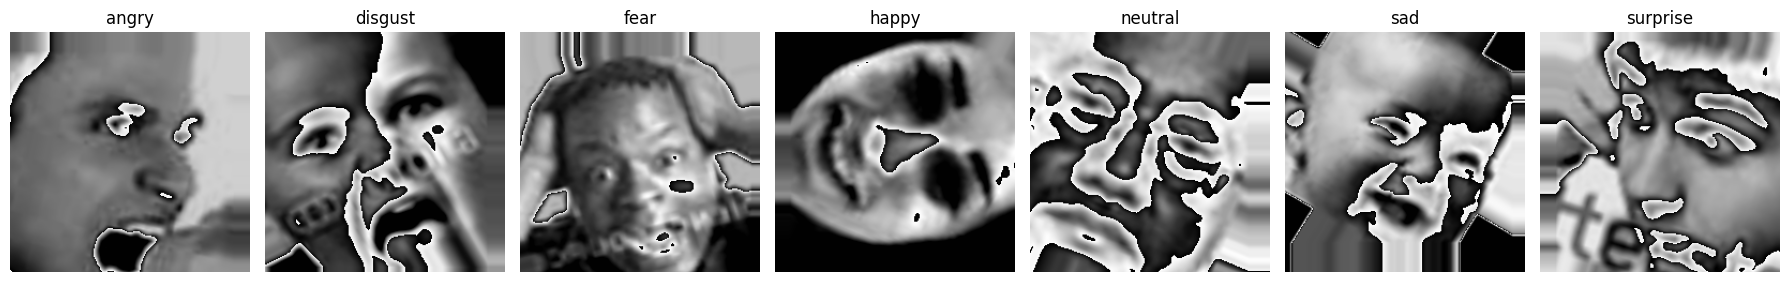

Per-class visualization for Training Dataset rendered.

--- Visualizing one image per class from Validation Dataset Pipeline ---


All classes collected.
Image 0: Scaling values from 0-1 to 0-255 for display (consistent).
Image 1: Scaling values from 0-1 to 0-255 for display (consistent).
Image 2: Scaling values from 0-1 to 0-255 for display (consistent).
Image 3: Scaling values from 0-1 to 0-255 for display (consistent).
Image 4: Scaling values from 0-1 to 0-255 for display (consistent).
Image 5: Scaling values from 0-1 to 0-255 for display (consistent).
Image 6: Scaling values from 0-1 to 0-255 for display (consistent).
Rendering per-class visualization for Validation Dataset...


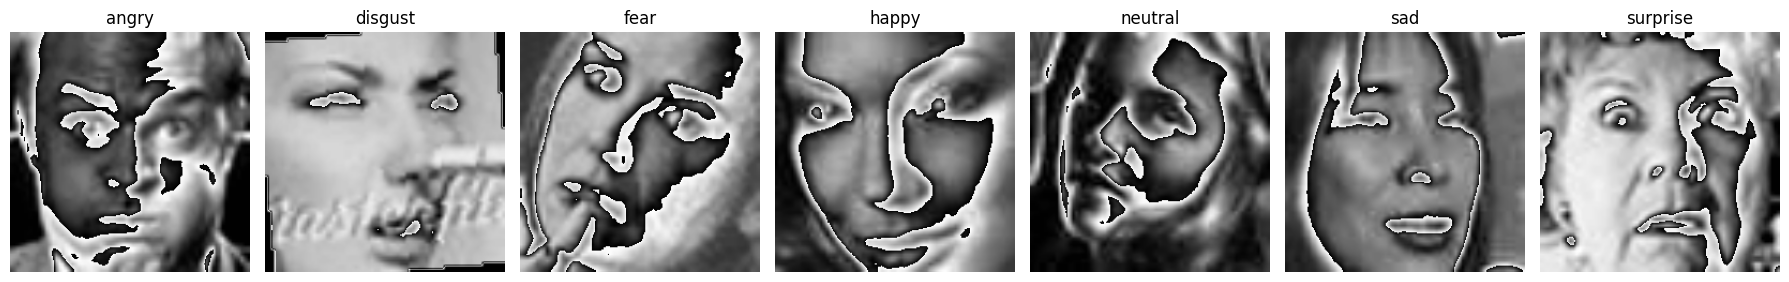

Per-class visualization for Validation Dataset rendered.


In [ ]:
# --- NEW Visualization Function: One Image Per Class from Pipeline ---
def visualize_one_image_per_class_from_pipeline(dataset, emotion_classes, dataset_name="Dataset"):
    """
    Collects and visualizes one random image for each emotion class from the dataset pipeline.
    Ensures all classes are represented and images are correctly processed/augmented.
    """
    print(f"\n--- Visualizing one image per class from {dataset_name} Pipeline ---")
    plt.close('all') # Close any existing plots

    collected_images = {} # Dictionary to store one image per class

    # Iterate through a portion of the dataset to collect samples for each class
    # Use .unbatch() to get individual (image, label) pairs.
    # .take(N) limits how many samples we iterate over for efficiency.
    # 2000 samples should be plenty to find all 7 classes in a balanced dataset.
    temp_unbatched_dataset = dataset.unbatch().take(2000)

    print(f"Collecting one image per class from {dataset_name}...")
    for image, label in tqdm(temp_unbatched_dataset, desc="Collecting samples"):
        label_idx = tf.argmax(label).numpy()
        if label_idx not in collected_images: # Only store the first encountered image for each class
            collected_images[label_idx] = image.numpy() # Store the numpy array

        if len(collected_images) == len(emotion_classes):
            print("All classes collected.")
            break # Stop early if all classes are found

    if len(collected_images) < len(emotion_classes):
        print(f"Warning: Could not collect an image for all {len(emotion_classes)} classes. Found {len(collected_images)} classes.")

    # Now plot the collected images
    if not collected_images:
        print(f"No images collected from {dataset_name} for per-class visualization.")
        return

    plt.figure(figsize=(18, 6)) # Adjust figure size as needed (1 row, 7 columns for 7 emotions)

    # Sort by class index for consistent plotting order
    sorted_classes = sorted(collected_images.keys())

    for i, class_idx in enumerate(sorted_classes):
        img_to_display = collected_images[class_idx]

        ax = plt.subplot(1, len(emotion_classes), i + 1) # One row, N columns

        # Determine scaling for display based on pixel range
        min_val = np.min(img_to_display)
        max_val = np.max(img_to_display)


        img_to_display = (img_to_display * 255).astype(np.uint8)
        print(f"Image {i}: Scaling values from 0-1 to 0-255 for display (consistent).") # Updated print


        plt.imshow(img_to_display)
        plt.title(emotion_classes[class_idx])
        plt.axis('off')

    plt.tight_layout()
    print(f"Rendering per-class visualization for {dataset_name}...")
    plt.show()
    print(f"Per-class visualization for {dataset_name} rendered.")
# --- ADD THESE VISUALIZATION CALLS HERE ---
visualize_pipeline_batch(train_dataset, num_images=9, dataset_name="Training Dataset (with Augmentation)")
visualize_pipeline_batch(val_dataset, num_images=9, dataset_name="Validation Dataset (no Augmentation)")

visualize_one_image_per_class_from_pipeline(train_dataset, EMOTION_CLASSES, dataset_name="Training Dataset")
visualize_one_image_per_class_from_pipeline(val_dataset, EMOTION_CLASSES, dataset_name="Validation Dataset")
# --- END VISUALIZATION CALLS ---

#Build model

In [ ]:
# ... (rest of your imports and configuration) ...

# --- Model Building Function (ResNet50V2) ---
def build_model(base_model_trainable=False):
    """
    Builds the CNN model using ResNet50V2 as a base,
    with an expanded custom classification head and SpatialChannelAttention.
    """
    with strategy.scope():
        # Input tensor (IMAGE_SIZE x 3 for RGB)
        inputs = tf.keras.layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), name='input_image')

        # Load pre-trained ResNet50V2 base model
        base_model = tf.keras.applications.ResNet50V2(
            weights='imagenet',
            include_top=False, # Do not include the classification head
            input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
            pooling=None, # We'll add our own pooling layer
            # REMOVED: include_preprocessing=False # This argument is not supported by ResNet50V2
        )
        base_model.trainable = base_model_trainable # Set base model's trainable state

        x = base_model(inputs, training=base_model_trainable) # Pass through base model

        # Add custom layers
        x = SpatialChannelAttention(name='spatial_channel_attention')(x)
        x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pooling')(x)

        # --- Expanded Classification Head ---
        x = tf.keras.layers.Dense(512, activation='relu', name='dense_new_512')(x)
        x = tf.keras.layers.BatchNormalization(name='batch_norm_new')(x)
        x = tf.keras.layers.Dropout(0.6, name='dropout_new_0.6')(x)

        x = tf.keras.layers.Dense(256, activation='relu', name='dense_1')(x)
        x = tf.keras.layers.BatchNormalization(name='batch_norm')(x)
        x = tf.keras.layers.Dropout(0.6, name='dropout_1')(x)

        # Output layer with 7 neurons (for 7 emotion classes) and softmax activation
        outputs = tf.keras.layers.Dense(len(EMOTION_CLASSES), activation='softmax', dtype='float32', name='output_layer')(x)

        model = tf.keras.Model(inputs, outputs, name='emotion_recognition_resnet_model')
        return model, base_model # Return both the compiled model and the base_model for control

In [ ]:
    # --- Callbacks ---
    class TrainingProgressBar(Callback):
        """Custom Keras Callback to display a progress bar for each epoch."""
        def __init__(self, steps_per_epoch, total_epochs, name="Training"):
            super().__init__()
            self.steps_per_epoch = steps_per_epoch
            self.total_epochs = total_epochs
            self.name = name

        def on_epoch_begin(self, epoch, logs=None):
            self.epoch_progress = tqdm(total=self.steps_per_epoch,
                                         desc=f"{self.name} Epoch {epoch + 1}/{self.total_epochs}")

        def on_batch_end(self, batch, logs=None):
            self.epoch_progress.update(1)
            loss_val = logs.get("loss", 0.0)
            acc_val = logs.get("accuracy", 0.0)
            self.epoch_progress.set_postfix({'loss': f'{loss_val:.4f}', 'acc': f'{acc_val:.4f}'})

        def on_epoch_end(self, epoch, logs=None):
            self.epoch_progress.close()
            gc.collect()

    class PerformanceMonitor(Callback):
        """
        Custom Keras Callback to calculate and log detailed validation metrics
        (confusion matrix, classification report) at the end of each epoch.
        """
        def __init__(self, val_dataset, emotion_classes, output_dir, monitor_steps=128, global_epoch_offset=0):
            super().__init__()
            self.val_dataset = val_dataset
            self.emotion_classes = emotion_classes
            self.output_dir = output_dir
            self.monitor_steps = monitor_steps
            self.global_epoch_offset = global_epoch_offset # NEW: Offset for global epoch calculation

            metrics_log_path = os.path.join(output_dir, 'epoch_metrics.csv')
            self.metrics_log = pd.DataFrame() # Start with an empty DataFrame by default
            if os.path.exists(metrics_log_path):
                try:
                    # Attempt to load existing log
                    temp_df = pd.read_csv(metrics_log_path)
                    # CRITICAL INTEGRITY CHECK: Ensure 'epoch' column is numeric and monotonically increasing
                    if 'epoch' in temp_df.columns and \
                       pd.to_numeric(temp_df['epoch'], errors='coerce').notna().all() and \
                       temp_df['epoch'].is_monotonic_increasing:
                        self.metrics_log = temp_df
                        print(f"Successfully loaded existing epoch_metrics.csv from {metrics_log_path}.")
                    else:
                        print(f"Warning: Existing epoch_metrics.csv at {metrics_log_path} is malformed or not monotonic. Starting a new log for this run.")
                except Exception as e:
                    print(f"Error loading epoch_metrics.csv at {metrics_log_path}: {e}. Starting a new log for this run.")


        def on_epoch_end(self, epoch, logs=None):
            # Calculate the true global epoch number
            global_epoch = self.global_epoch_offset + epoch + 1

            print(f"\n--- Running detailed validation metrics for Global Epoch {global_epoch} ---")
            y_true, y_pred = [], []

            for images, labels in self.val_dataset.take(self.monitor_steps):
                pred = self.model.predict(images, verbose=0)
                y_pred.extend(np.argmax(pred, axis=1))
                y_true.extend(np.argmax(labels.numpy(), axis=1))

            if not y_true:
                print("No validation samples processed for detailed metrics.")
                return

            cm = confusion_matrix(y_true, y_pred, labels=range(len(self.emotion_classes)))
            report = classification_report(y_true, y_pred, target_names=self.emotion_classes, output_dict=True, zero_division=0)

            epoch_metrics = {
                'epoch': global_epoch, # Use the calculated global epoch here
                'val_acc': logs.get('val_accuracy', 0.0),
                'val_loss': logs.get('val_loss', 0.0),
                'val_precision_macro': report['macro avg']['precision'],
                'val_recall_macro': report['macro avg']['recall'],
                'val_f1_macro': report['macro avg']['f1-score'],
                'val_precision_weighted': report['weighted avg']['precision'],
                'val_recall_weighted': report['weighted avg']['recall'],
                'val_f1_weighted': report['weighted avg']['f1-score']
            }

            for cls_name in self.emotion_classes:
                epoch_metrics[f'{cls_name}_precision'] = report[cls_name]['precision']
                epoch_metrics[f'{cls_name}_recall'] = report[cls_name]['recall']
                epoch_metrics[f'{cls_name}_f1'] = report[cls_name]['f1-score']

            # Concatenate the new epoch's metrics and save
            self.metrics_log = pd.concat([self.metrics_log, pd.DataFrame([epoch_metrics])], ignore_index=True)
            self.metrics_log.to_csv(os.path.join(self.output_dir, 'epoch_metrics.csv'), index=False)

            print(f"\nGlobal Epoch {global_epoch} Detailed Validation Metrics:")
            print(f"Overall Validation Accuracy: {epoch_metrics['val_acc']:.4f}")
            print(f"Overall Validation Loss: {epoch_metrics['val_loss']:.4f}")
            print("Macro Avg: Precision={:.4f}, Recall={:.4f}, F1={:.4f}".format(
                epoch_metrics['val_precision_macro'], epoch_metrics['val_recall_macro'], epoch_metrics['val_f1_macro']))
            print("Weighted Avg: Precision={:.4f}, Recall={:.4f}, F1={:.4f}".format(
                epoch_metrics['val_precision_weighted'], epoch_metrics['val_recall_weighted'], epoch_metrics['val_f1_weighted']))

            print("\nPer-Class Metrics:")
            for cls_name in self.emotion_classes:
                print(f"  {cls_name.ljust(10)}: Precision={epoch_metrics[f'{cls_name}_precision']:.4f}, "
                      f"Recall={epoch_metrics[f'{cls_name}_recall']:.4f}, "
                      f"F1={epoch_metrics[f'{cls_name}_f1']:.4f}")

            print("Detailed metrics saved to epoch_metrics.csv")

            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=self.emotion_classes, yticklabels=self.emotion_classes)
            plt.title(f'Confusion Matrix - Global Epoch {global_epoch}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
            plt.savefig(os.path.join(self.output_dir, f'confusion_matrix_global_epoch_{global_epoch}.png'))
            plt.close()
            gc.collect()


In [ ]:
+# --- Main Training Logic Function ---
def train_model():
    """
    Orchestrates the multi-phase training pipeline with resume capability:
    1. Feature Extraction (Base Model Frozen)
    2. Partial Fine-tuning (Top layers of Base Model unfrozen)
    3. Full Fine-tuning (Entire Base Model unfrozen)
    """
    start_total_time = time.time()
    final_model = None
    history_fe = None
    history_pt = None
    history_ft = None

    # --- Resume Logic Variables ---
    current_phase = 1  # Default to start from Phase 1
    initial_epoch_fe = 0
    initial_epoch_pt = 0
    initial_epoch_ft = 0
    last_global_epoch = 0

    # Check for existing checkpoints to determine resume point
    best_ft_path = os.path.join(OUTPUT_DIR, 'best_ft_weights.weights.h5')
    best_pt_path = os.path.join(OUTPUT_DIR, 'best_pt_weights.weights.h5')
    best_fe_path = os.path.join(OUTPUT_DIR, 'best_fe_weights.weights.h5')
    metrics_log_path = os.path.join(OUTPUT_DIR, 'epoch_metrics.csv')

    # Determine the actual number of epochs completed in each phase
    if os.path.exists(metrics_log_path):
        try:
            metrics_df = pd.read_csv(metrics_log_path)
            if not metrics_df.empty:
                metrics_df['epoch'] = pd.to_numeric(metrics_df['epoch'], errors='coerce')
                metrics_df.dropna(subset=['epoch'], inplace=True)
                metrics_df = metrics_df.sort_values(by='epoch').reset_index(drop=True)

                if not metrics_df.empty and metrics_df['epoch'].is_monotonic_increasing:
                    last_global_epoch = int(metrics_df['epoch'].max())
                    print(f"Detected last recorded global epoch in metrics: {last_global_epoch}.")

                    if last_global_epoch >= (FEATURE_EXTRACT_EPOCHS + PARTIAL_FINE_TUNE_EPOCHS):
                        current_phase = 3
                        initial_epoch_ft = last_global_epoch - (FEATURE_EXTRACT_EPOCHS + PARTIAL_FINE_TUNE_EPOCHS)
                        print(f"Resuming from Full Fine-tuning phase. Detected {initial_epoch_ft} FT epochs completed.")
                        print(f"Resuming FT from its epoch {initial_epoch_ft + 1}.")
                    elif last_global_epoch >= FEATURE_EXTRACT_EPOCHS:
                        current_phase = 2
                        initial_epoch_pt = last_global_epoch - FEATURE_EXTRACT_EPOCHS
                        print(f"Resuming from Partial Fine-tuning phase. Detected {initial_epoch_pt} PT epochs completed.")
                        print(f"Resuming PT from its epoch {initial_epoch_pt + 1}.")
                    else:
                        current_phase = 1
                        initial_epoch_fe = last_global_epoch
                        print(f"Resuming from Feature Extraction phase. Detected {initial_epoch_fe} FE epochs completed.")
                        print(f"Resuming FE from its epoch {initial_epoch_fe + 1}.")
                else:
                    print("Warning: epoch_metrics.csv found but is malformed or not monotonic. Starting fresh log.")
        except Exception as e:
            print(f"Error reading epoch_metrics.csv: {e}. Starting fresh log.")

    if current_phase == 1 and initial_epoch_fe == 0 and not os.path.exists(best_fe_path):
        print("\nNo previous checkpoints found. Starting training from scratch (Phase 1).")

    try:
        # -------------------- PHASE 1: Feature Extraction --------------------
        if current_phase <= 1:
            print("\n" + "="*80)
            print("--- Phase 1: Feature Extraction (Base Model Frozen) ---")
            print("="*80)

            with strategy.scope():
                model_fe, base_model_fe = build_model(base_model_trainable=False)
                optimizer_fe = AdamW(learning_rate=INITIAL_LR_FE, weight_decay=0.001)
                model_fe.compile(
                    optimizer=optimizer_fe,
                    loss=FocalLoss(gamma=2.5, alpha=list(class_weights.values())),
                    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
                )

                if initial_epoch_fe > 0 and os.path.exists(best_fe_path):
                    print(f"Loading weights for FE phase from: {best_fe_path}")
                    model_fe.load_weights(best_fe_path)
                elif initial_epoch_fe > 0:
                    print("Warning: FE resume requested but best_fe_weights.weights.h5 not found. Starting FE from scratch.")
                    initial_epoch_fe = 0

                print("\n--- Model Summary (Feature Extraction Phase) ---")
                model_fe.summary()
                print("--- End Model Summary ---")

            callbacks_fe = [
                TrainingProgressBar(train_steps, FEATURE_EXTRACT_EPOCHS, name="FE"),
                PerformanceMonitor(val_dataset, EMOTION_CLASSES, OUTPUT_DIR, global_epoch_offset=0),
                ModelCheckpoint(filepath=best_fe_path, monitor='val_accuracy', mode='max', save_best_only=True, save_weights_only=True),
                EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7)
            ]

            print(f"\nStarting Feature Extraction for {FEATURE_EXTRACT_EPOCHS - initial_epoch_fe} more epochs...")
            history_fe = model_fe.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=FEATURE_EXTRACT_EPOCHS,
                initial_epoch=initial_epoch_fe,
                steps_per_epoch=train_steps,
                validation_steps=val_steps,
                callbacks=callbacks_fe,
                verbose=0
            )
            print("Feature Extraction Phase Completed.")
            gc.collect()
            current_phase = 2

        # -------------------- PHASE 2: Partial Fine-tuning --------------------
        if current_phase <= 2:
            print("\n" + "="*80)
            print("--- Phase 2: Partial Fine-tuning (Unfreeze top layers of Base Model) ---")
            print("="*80)

            with strategy.scope():
                model_pt, base_model_pt = build_model(base_model_trainable=True)

                if os.path.exists(best_pt_path):
                    print(f"Loading weights for PT phase from: {best_pt_path}")
                    model_pt.load_weights(best_pt_path)
                elif os.path.exists(best_fe_path):
                    print(f"Loading best weights from Feature Extraction phase: {best_fe_path}")
                    model_pt.load_weights(best_fe_path)
                    initial_epoch_pt = 0
                else:
                    print("Warning: No suitable weights found for PT phase. Starting with random PT weights.")
                    initial_epoch_pt = 0

                num_base_layers = len(base_model_pt.layers)
                unfreeze_from_index = int(num_base_layers * 0.8)

                print(f"Unfreezing approximately {num_base_layers - unfreeze_from_index} layers.")
                for i, layer in enumerate(base_model_pt.layers):
                    layer.trainable = (i >= unfreeze_from_index)

                optimizer_pt = AdamW(learning_rate=INITIAL_LR_PT, weight_decay=0.001)
                model_pt.compile(
                    optimizer=optimizer_pt,
                    loss=FocalLoss(gamma=2.5, alpha=list(class_weights.values())),
                    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
                )
                print("\n--- Model Summary (Partial Fine-tuning Phase) ---")
                model_pt.summary()
                print("--- End Model Summary ---")

            pt_global_offset = FEATURE_EXTRACT_EPOCHS
            callbacks_pt = [
                TrainingProgressBar(train_steps, PARTIAL_FINE_TUNE_EPOCHS, name="PT"),
                PerformanceMonitor(val_dataset, EMOTION_CLASSES, OUTPUT_DIR, global_epoch_offset=pt_global_offset),
                ModelCheckpoint(filepath=best_pt_path, monitor='val_accuracy', mode='max', save_best_only=True, save_weights_only=True),
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-8)
            ]

            print(f"\nStarting Partial Fine-tuning for {PARTIAL_FINE_TUNE_EPOCHS - initial_epoch_pt} more epochs...")
            history_pt = model_pt.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=PARTIAL_FINE_TUNE_EPOCHS,
                initial_epoch=initial_epoch_pt,
                steps_per_epoch=train_steps,
                validation_steps=val_steps,
                callbacks=callbacks_pt,
                verbose=0
            )
            print("Partial Fine-tuning Phase Completed.")
            gc.collect()
            current_phase = 3

        # -------------------- PHASE 3: Full Fine-tuning --------------------
        if current_phase <= 3:
            print("\n" + "="*80)
            print("--- Phase 3: Full Fine-tuning (Unfreeze entire Base Model) ---")
            print("="*80)

            with strategy.scope():
                model_ft, base_model_ft = build_model(base_model_trainable=True)

                if os.path.exists(best_ft_path):
                    print(f"Loading weights for FT phase from: {best_ft_path}")
                    model_ft.load_weights(best_ft_path)
                elif os.path.exists(best_pt_path):
                    print(f"Loading best weights from Partial Fine-tuning phase: {best_pt_path}")
                    model_ft.load_weights(best_pt_path)
                    initial_epoch_ft = 0
                else:
                    print("Warning: No suitable weights found for FT phase. Starting with random FT weights.")
                    initial_epoch_ft = 0

                print("Unfreezing ALL layers of the base model for Full Fine-tuning.")
                for layer in base_model_ft.layers:
                    layer.trainable = True

                optimizer_ft = AdamW(learning_rate=INITIAL_LR_FT, weight_decay=0.001)
                model_ft.compile(
                    optimizer=optimizer_ft,
                    loss=FocalLoss(gamma=2.5, alpha=list(class_weights.values())),
                    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
                )
                print("\n--- Model Summary (Full Fine-tuning Phase) ---")
                model_ft.summary()
                print("--- End Model Summary ---")

            ft_global_offset = FEATURE_EXTRACT_EPOCHS + PARTIAL_FINE_TUNE_EPOCHS
            callbacks_ft = [
                TrainingProgressBar(train_steps, FULL_FINE_TUNE_EPOCHS, name="FT"),
                PerformanceMonitor(val_dataset, EMOTION_CLASSES, OUTPUT_DIR, global_epoch_offset=ft_global_offset),
                ModelCheckpoint(filepath=best_ft_path, monitor='val_accuracy', mode='max', save_best_only=True, save_weights_only=True),
                EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-9)
            ]

            print(f"\nStarting Full Fine-tuning for {FULL_FINE_TUNE_EPOCHS - initial_epoch_ft} more epochs...")
            history_ft = model_ft.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=FULL_FINE_TUNE_EPOCHS,
                initial_epoch=initial_epoch_ft,
                steps_per_epoch=train_steps,
                validation_steps=val_steps,
                callbacks=callbacks_ft,
                verbose=0
            )
            print("Full Fine-tuning Phase Completed.")
            gc.collect()
            final_model = model_ft

    except Exception as e:
        print(f"An error occurred during training: {e}")
        if 'model_fe' in locals() and model_fe is not None:
            model_fe.save(os.path.join(OUTPUT_DIR, 'model_fe_error_state.h5'))
        if 'model_pt' in locals() and model_pt is not None:
            model_pt.save(os.path.join(OUTPUT_DIR, 'model_pt_error_state.h5'))
        if 'model_ft' in locals() and model_ft is not None:
            model_ft.save(os.path.join(OUTPUT_DIR, 'model_ft_error_state.h5'))
        raise

    finally:
        end_total_time = time.time()
        print(f"\nTotal training pipeline finished in {(end_total_time - start_total_time) / 3600:.2f} hours.")
        print("--- Final Evaluation on Test Set ---")
        if final_model:
            print(f"Evaluating the best fine-tuned model (from Phase 3) on the test set ({test_samples} samples)...")
            test_results = final_model.evaluate(test_dataset, steps=test_steps, verbose=1)
            print(f"Test Loss: {test_results[0]:.4f}, Test Accuracy: {test_results[1]:.4f}")
            print(f"Test Precision: {test_results[2]:.4f}, Test Recall: {test_results[3]:.4f}")

            test_results_path = os.path.join(OUTPUT_DIR, 'final_test_results.txt')
            with open(test_results_path, 'w') as f:
                f.write(f"Final Test Loss: {test_results[0]:.4f}\n")
                f.write(f"Final Test Accuracy: {test_results[1]:.4f}\n")
                f.write(f"Final Test Precision: {test_results[2]:.4f}\n")
                f.write(f"Final Test Recall: {test_results[3]:.4f}\n")
            print(f"Final test results saved to {test_results_path}")

            final_model_save_path = os.path.join(OUTPUT_DIR, 'final_resnet_emotion_model.h5')
            print(f"Saving final model to {final_model_save_path}")
            final_model.save(final_model_save_path)
            print("Final model saved.")
        else:
            print("No final model to evaluate due to earlier error.")
        # Add your evaluation and history plotting logic here as per original code...

# --- Execute the training pipeline ---
if __name__ == "__main__":
    train_model()


Detected last recorded global epoch in metrics: 100.
Resuming from Full Fine-tuning phase. Detected 60 FT epochs completed.
Resuming FT from its epoch 61.

--- Phase 3: Full Fine-tuning (Unfreeze entire Base Model) ---
Loading weights for FT phase from: /content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/resnet_models_run_20250804-112056/best_ft_weights.weights.h5
Unfreezing ALL layers of the base model for Full Fine-tuning.

--- Model Summary (Full Fine-tuning Phase) ---


Model: "emotion_recognition_resnet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_channel_attention       │ (None, 7, 7, 2048)     │     1,069,312 │
│ (SpatialChannelAttention)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pooling              │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_new_512 (Dense)           │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_new                  │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_new_0.6 (Dropout)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_3 (Cast)                   │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,819,399 (98.49 MB)

 Trainable params: 25,772,423 (98.31 MB)

 Non-trainable params: 46,976 (183.50 KB)

--- End Model Summary ---
Successfully loaded existing epoch_metrics.csv from /content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/resnet_models_run_20250804-112056/epoch_metrics.csv.

Starting Full Fine-tuning for 0 more epochs...
Full Fine-tuning Phase Completed.

Total training pipeline finished in 0.01 hours.
--- Final Evaluation on Test Set ---
Evaluating the best fine-tuned model (from Phase 3) on the test set (6286 samples)...
785/785 ━━━━━━━━━━━━━━━━━━━━ 152s 169ms/step - accuracy: 0.6360 - loss: 0.5942 - precision_1: 0.7600 - recall_1: 0.5027


Test Loss: 0.5863, Test Accuracy: 0.6334
Test Precision: 0.7575, Test Recall: 0.5038
Final test results saved to /content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/resnet_models_run_20250804-112056/final_test_results.txt
Saving final model to /content/drive/MyDrive/snap_tune_project/balanced_datasets_fer2013/resnet_models_run_20250804-112056/final_resnet_emotion_model.h5
Final model saved.
